Librerías y constantes globales necesarias para el modelo

In [1]:
#Importamos las librerías que necesitaremos para calculos numéricos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from dataclasses import dataclass
from scipy.optimize import minimize_scalar
from scipy.integrate import simpson
!pip install astroquery
from astroquery.vizier import Vizier


#Creamos un clase para la composición química
@dataclass
class Composicion:

    X: float
    Y: float
    Z: float
    mu: float
    C_m: float
    C_p: float
    C_l: float
    C_t: float
    C_t_conv: float


def crear_composicion(X, Y):
    Z = 1 - X - Y
    mu = 1 / (2*X + 3*Y/4 + Z/2)
    return Composicion(
        X=X, Y=Y, Z=Z, mu=mu,
        C_m = 0.01523 * mu,
        C_p = 8.084 * mu,
        C_l = 0.01845 * mu**2,
        C_t = 0.01679 * Z * (1 + X) * mu**2,
        C_t_conv = 3.234 * mu,
    )


# Parámetros iniciales del modelo
X_0 = 0.85
Y_0 = 0.10
R_Tot = 12
L_Tot = 25
M_Tot = 5.1
T_C = 1.5
comp_0 = crear_composicion(X_0, Y_0)



# Constantes físicas en CGS
c_cgs    = 2.998e10
G_cgs    = 6.674e-8
sigma    = 5.670374e-5
H_cgs    = 1.6735e-24
k_cgs    = 1.3807e-16

# Unidades solares
L_sol    = 3.828e33
R_sol    = 6.957e10
M_sol    = 1.989e33

# Conversiones
seg_por_año = 3.156e7
t_sol_MS    = 1e10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00


Generacion de energia

In [2]:
def epsilon(P, T, comp): # Función para la generación de energía, devuelve el valor y un string para diferenciar que proceso es dominante

    eps_1_pp, nu_pp = 0.0, 0.0
    eps_1_cn, nu_cn = 0.0, 0.0

    #Cadena PP
    if 0.4 <= T < 0.6:
        eps_1_pp, nu_pp = 10**-6.84, 6.0
    elif 0.6 <= T < 0.95:
        eps_1_pp, nu_pp = 10**-6.04, 5.0
    elif 0.95 <= T < 1.2:
        eps_1_pp, nu_pp = 10**-5.56, 4.5
    elif 1.2 <= T < 1.65:
        eps_1_pp, nu_pp = 10**-5.02, 4.0
    elif 1.65 <= T < 2.4:
        eps_1_pp, nu_pp = 10**-4.40, 3.5

    # Ciclo CN
    if 1.2 <= T < 1.6:
        eps_1_cn, nu_cn = 10**-22.2, 20
    elif 1.6 <= T < 2.25:
        eps_1_cn, nu_cn = 10**-19.8, 18
    elif 2.25 <= T < 2.75:
        eps_1_cn, nu_cn = 10**-17.1, 16
    elif 2.75 <= T < 3.6:
        eps_1_cn, nu_cn = 10**-15.6, 15
    elif 3.6 <= T < 5.0:
        eps_1_cn, nu_cn = 10**-12.5, 13

    eps_PP = comp.X**2 * eps_1_pp * comp.C_l * 10**nu_pp * P**2 * T**(nu_pp - 2)
    eps_CN = comp.X * comp.Z / 3 * eps_1_cn * comp.C_l * 10**nu_cn * P**2 * T**(nu_cn - 2)

    if T < 0.4 or (eps_PP == 0 and eps_CN == 0):
        return 0.0, '--'
    elif eps_PP >= eps_CN:
        return eps_PP, 'PP'
    else:
        return eps_CN, 'CNO'


Pasos intermedios de cálculo de los algoritmos

In [3]:
def capas_rad(r, M, L, R, comp):                       # Calculo teórico de capas radiativas
    A_1 = 1.9022 * comp.mu * M
    A_2 = 10.645 * np.sqrt(M / (comp.mu * comp.Z * (1 + comp.X) * L))

    T = A_1 * (1/r - 1/R)
    P = A_2 * T**4.25
    dP = -comp.C_p * P * M / (T * r**2)
    dT = -comp.C_t * P**2 * L / (T**8.5 * r**2)

    return P, T, dP, dT


def capas_con(r, K, T_C, comp):             # Calculo teórico de capas convectivac
    M = 0.005077 * comp.mu * K * T_C**1.5 * r**3
    T = T_C - 0.008207 * comp.mu**2 * K * T_C**1.5 * r**2
    P_C = K * T_C**2.5
    eps_c, _ = epsilon(P_C, T_C, comp)
    L = eps_c * r**3 / 3
    P = K * T**2.5
    if r == 0:
        dP = 0
        dT = 0
        dL = 0
        dM = 0
    else:
        eps, _ = epsilon(P, T, comp)
        dM = comp.C_m * K * T**1.5 * r**2
        dP = -comp.C_p * K * T**1.5 * M / r**2
        dT = -comp.C_t_conv * M / r**2
        dL = eps * r**2

    return P, T, L, M, dP, dT, dM, dL


# Pasos del algoritmo radiativo
def paso_1(r, h):
    return r + h


def paso_2(P_i, T_i, dPi, dTi, dP_i, dP__i, dT_i, h):
    delta_P_1 = h * (dPi - dP_i)
    delta_P_2 = h * (dPi - 2 * dP_i + dP__i)
    delta_T_1 = h * (dTi - dT_i)

    P = P_i + h * dPi + delta_P_1/2 + 5 * delta_P_2/12
    T = T_i + h * dTi + delta_T_1/2
    return P, T


def paso_3(P_e, T_e, r, Mi, dM_i, h, comp):
    dM = comp.C_m * P_e / T_e * r**2
    delta = h * (dM - dM_i)
    M = Mi + h * dM - delta/2
    return M, dM


def paso_4(P_e, P_i, T_e, r, dP_i, M, h, comp):
    dP = -comp.C_p * P_e * M / (T_e * r**2)
    delta = h * (dP - dP_i)
    P_c = P_i + h * dP - delta/2
    return P_c, dP


def paso_6(eps, r, Li, dLi, dLi_, h):
    dL = eps * r**2
    delta1 = h * (dL - dLi)
    delta2 = h * (dL - 2 * dLi + dLi_)
    L = Li + h * dL - delta1/2 - delta2/12
    return L, dL


def paso_7(P_c, T_e, Ti, dTi, L_c, r, h, comp):
    dT = -comp.C_t * P_c**2 * L_c / (T_e**8.5 * r**2)
    delta = h * (dT - dTi)
    T_c = Ti + h * dT - delta/2
    return T_c, dT


def paso_9(P_c, T_c, dP, dT):
    return T_c * dP / (P_c * dT)


# Pasos del núcleo convectivo
def paso_2b(Ti, dTi, dTi_, h):
    delta = h * (dTi - dTi_)
    T = Ti + h * dTi + delta/2
    return T


def paso_pol(K, T):
    return K * T**2.5


def paso_7b(r, T_e, Ti, dTi, M_c, h, comp):
    if abs(r) <= 1e-10:
        T_c = T_e
        dT = dTi
    else:
        dT = -comp.C_t_conv * M_c / r**2
        delta = h * (dT - dTi)
        T_c = Ti + h * dT - delta/2
    return T_c, dT


Integración desde la superficie (zona radiativa)

In [4]:
def integrar_envoltura(R, L, M, comp):             # Calcula las capas radiativas mediante el algoritmo A.1
    array_1 = []  # Datos [r, P, T, L, M, m]
    array_2 = []  # Pendientes [dP, dT, dL, dM]

    R_in = 0.9 * R
    h = -R_in / 100

    i = 0

    while True:
        if i == 0:
            r = R_in
            P, T, dP, dT = capas_rad(r, M, L, R, comp)

            array_1.append([r, P, T, L, M, 0])
            array_2.append([dP, dT, 0, 0])
            i += 1
        elif 0 < i < 3:
            r = paso_1(r, h)
            P, T, dP, dT = capas_rad(r, M, L, R, comp)
            array_1.append([r, P, T, L, M, 0])
            array_2.append([dP, dT, 0, 0])
            i += 1
        else:
            r = paso_1(r, h)
            P_i = array_1[i-1][1]
            T_i = array_1[i-1][2]
            dPi = array_2[i-1][0]
            dTi = array_2[i-1][1]
            dP_i = array_2[i-2][0]
            dP__i = array_2[i-3][0]
            dT_i = array_2[i-2][1]
            Mi = array_1[i-1][4]
            dM_i = array_2[i-1][3]
            Li = array_1[i-1][3]
            dLi = array_2[i-1][2]
            dLi_ = array_2[i-2][2]

            P, T = paso_2(P_i, T_i, dPi, dTi, dP_i, dP__i, dT_i, h)

            while True:  # Loop 2

                while True:  # Loop 3
                    M, dM = paso_3(P, T, r, Mi, dM_i, h, comp)
                    P_c, dP = paso_4(P, P_i, T, r, dPi, M, h, comp)

                    if abs((P_c - P))/P_c < 0.0001:
                        break
                    else:
                        P = P_c

                eps, _ = epsilon(P_c, T, comp)
                L, dL = paso_6(eps, r, Li, dLi, dLi_, h)

                T_c, dT = paso_7(P_c, T, T_i, dTi, L, r, h, comp)

                if abs((T_c - T))/T_c < 0.0001:
                    break
                else:
                    T = T_c
                    P = P_c

            m = paso_9(P_c, T_c, dP, dT)
            if m >= 2.5:
                array_1.append([r, P_c, T_c, L, M, m])
                array_2.append([dP, dT, dL, dM])
                i += 1
            else:
                array_1.append([r, P_c, T_c, L, M, m])
                array_2.append([dP, dT, dL, dM])
                break

    array_1 = np.array(array_1)
    array_2 = np.array(array_2)
    return i, array_1, array_2


formatos_var = {
    'r': '{:.6f}'.format,
    'P': '{:.7f}'.format,
    'T': '{:.7f}'.format,
    'L': '{:.6f}'.format,
    'M': '{:.6f}'.format,
    'm': '{:.6f}'.format
}


Integración desde la superficie (zona convectiva)

In [5]:
def integrar_superficie_convectiva(variables, pendientes, i_inter, comp):   # Integra la superficie convectiva (no se usa en el modelo final)mediante el algoritmo A.2
    P_conv, T_conv = variables[i_inter][1], variables[i_inter][2]
    K_pol = P_conv / T_conv**2.5

    R_in = variables[0][0]
    h = -R_in / 100
    i = i_inter
    variables = list(variables)
    pendientes = list(pendientes)

    while True:
        if i == i_inter:
            r = variables[i][0]
            m = variables[i][5]
        else:
            r = paso_1(r, h)
            m = 0
        Pi = variables[i - 1][1]
        Ti = variables[i - 1][2]
        dPi = pendientes[i - 1][0]
        dPi_ = pendientes[i - 2][0]
        dTi = pendientes[i - 1][1]
        dTi_ = pendientes[i - 2][1]
        Li = variables[i - 1][3]
        dLi = pendientes[i - 1][2]
        dLi_ = pendientes[i - 2][2]
        Mi = variables[i - 1][4]
        dMi = pendientes[i - 1][3]
        dMi_ = pendientes[i - 2][3]

        T = paso_2b(Ti, dTi, dTi_, h)

        while True:
            P = paso_pol(K_pol, T)
            M, dM = paso_3(P, T, r, Mi, dMi, h, comp)
            T_c, dT = paso_7b(r, T, Ti, dTi, M, h, comp)

            if abs((T_c - T))/T_c <= 0.0001:
                break
            else:
                T = T_c

        P_c = paso_pol(K_pol, T_c)

        eps, _ = epsilon(P_c, T_c, comp)
        L, dL = paso_6(eps, r, Li, dLi, dLi_, h)
        dP = 0
        variables.append([r, P_c, T_c, L, M, m])
        pendientes.append([dP, dT, dL, dM])

        i += 1

        if r <= 0:
            break

    variables = np.array(variables)
    pendientes = np.array(pendientes)
    return variables, pendientes, K_pol


Integración desde el centro

In [6]:
def integrar_nucleo(T_C, K, r_ajuste, comp, R):           # Integra la región convectiva según el algoritmo A.2
    h = 0.9 * R / 100
    i = 0
    variables = []   # Datos [r, P, T, L, M, m]
    pendientes = []

    while True:
        if i == 0:
            r = 0
            P, T, L, M, dP, dT, dM, dL = capas_con(r, K, T_C, comp)
            variables.append([r, P, T, L, M, 0])
            pendientes.append([dP, dT, dL, dM])
            i += 1
        elif 0 < i < 3:
            r = paso_1(r, h)
            P, T, L, M, dP, dT, dM, dL = capas_con(r, K, T_C, comp)
            variables.append([r, P, T, L, M, 0])
            pendientes.append([dP, dT, dL, dM])
            i += 1
        else:
            r = paso_1(r, h)

            Pi = variables[i - 1][1]
            Ti = variables[i - 1][2]
            dPi = pendientes[i - 1][0]
            dPi_ = pendientes[i - 2][0]
            dTi = pendientes[i - 1][1]
            dTi_ = pendientes[i - 2][1]
            Li = variables[i - 1][3]
            dLi = pendientes[i - 1][2]
            dLi_ = pendientes[i - 2][2]
            Mi = variables[i - 1][4]
            dMi = pendientes[i - 1][3]
            dMi_ = pendientes[i - 2][3]

            T = paso_2b(Ti, dTi, dTi_, h)

            while True:
                P = paso_pol(K, T)
                M, dM = paso_3(P, T, r, Mi, dMi, h, comp)
                T_c, dT = paso_7b(r, T, Ti, dTi, M, h, comp)

                if abs((T_c - T))/T_c <= 0.0001:
                    break
                else:
                    T = T_c

            P_c = paso_pol(K, T_c)

            eps, _ = epsilon(P_c, T_c, comp)
            L, dL = paso_6(eps, r, Li, dLi, dLi_, h)
            dP = 0
            variables.append([r, P_c, T_c, L, M, 0])
            pendientes.append([dP, dT, dL, dM])

            i += 1

            if r > r_ajuste:
                break

    variables = np.array(variables)
    pendientes = np.array(pendientes)
    return variables, pendientes


Interpolación de la capa intermedia y calculo del error cometido en la capa intermedia


In [7]:
def interpolacion(m1, m2, r1, r2, m) :  # Interpolamos por separado para obtener r en el que m = 2,5

  return r1 + ((r2 - r1) / (m2 - m1)) * (m - m1)


def interpolacion_Total(matriz_rad, matriz_conv, r_interpolado) : # Interpolamos para las dos últimas capas de la integración de superficie y del nucleo


  fila_1 = matriz_rad[-2]
  fila_2 = matriz_rad[-1]


  r1, r2 = matriz_rad[-2][0], matriz_rad[-1][0]



  fraccion = (r_interpolado - r1) / (r2 - r1)

  rad_interp = (fila_2 - fila_1) * fraccion + fila_1

  fila_3 = matriz_conv[-1]
  fila_4 = matriz_conv[-2]

  con_interp = (fila_4 - fila_3) * fraccion + fila_3

  return rad_interp, con_interp


def E_TOTAL(variables_r, variables_c) :   # Devuelve el error cometido entre las capas


  P_r, T_r, L_r, M_r = variables_r[1:5]
  P_c, T_c, L_c, M_c= variables_c[1:5]

  Er_P = (P_r - P_c) / P_r
  Er_T = (T_r - T_c) / T_r
  Er_L = (L_r - L_c) / L_r
  Er_M = (M_r - M_c) / M_r

  Er_Tot = np.sqrt(Er_P**2 + Er_T**2 + Er_L**2 + Er_M**2)

  return Er_Tot






Temperatura central para optimizar el error

In [8]:
# A partir de los valores radiativos, calcula la temperatura que minimiza el error devolviendo ambos
def optimizacion_T(T_C, K_pol, variables_rad, r_ajuste, comp, R):
    def funcion_objetivo(T_C): # La función de scipy solo acepta un argumento
        variables_conv, pendientes_conv = integrar_nucleo(T_C, K_pol, r_ajuste, comp, R)
        rad_interp, con_interp = interpolacion_Total(variables_rad, variables_conv, r_ajuste)
        return E_TOTAL(rad_interp, con_interp)

    resultado = minimize_scalar(
        funcion_objetivo,
        bounds=(T_C - 0.5, T_C + 0.5),
        method='bounded'
    )

    return resultado.fun, resultado.x


Modelo completo integrando las funciones previas

In [9]:
def ModeloCompleto(L, M, T_C, R, comp):
    variables = []
    pendientes = []
    primeras_capas = []
    primeras_capas_pend = []
    R_in = 0.9 * R
    h = -R_in / 100

    h_externas = R_in / 100
    r = R_in

    # Cálculo de las capas externas
    for i in range(12):
        r = paso_1(r, h_externas)
        if r >= R:   # cortafuegos por si el paso sobrepasa R
            r = R
            primeras_capas.append([r, 0, 0, L, M, 0])
            primeras_capas_pend.append([0, 0, 0, 0])
            break
        else:
            dL = 0
            dM = 0
            P, T, dP, dT = capas_rad(r, M, L, R, comp)
            primeras_capas.append([r, P, T, L, M, 0])
            primeras_capas_pend.append([dP, dT, dL, dM])

    # Invertimos para que queden ordenadas como en el guión
    primeras_capas = primeras_capas[::-1]
    primeras_capas_pend = primeras_capas_pend[::-1]

    # Integración desde la superficie
    _, array_rad, array_rad_pend = integrar_envoltura(R, L, M, comp)

    P_conv, T_conv = array_rad[-1][1], array_rad[-1][2]
    K_pol = P_conv / T_conv**2.5
    m_ajuste = 2.5


    r_ajuste = interpolacion(array_rad[-2][5], array_rad[-1][5],
                              array_rad[-2][0], array_rad[-1][0], m_ajuste)

    # Optimización de la temperatura central
    error_optimizado, TC_optimizado = optimizacion_T(T_C, K_pol, array_rad, r_ajuste, comp, R)

    # Integración desde el centro con la T_C óptima
    array_conv, array_conv_pend = integrar_nucleo(TC_optimizado, K_pol, r_ajuste, comp, R)

    # Quitamos la última capa radiativa (donde empieza la convección)
    array_rad = array_rad[:-1]
    array_rad_pend = array_rad_pend[:-1]

    # Invertimos la integración desde el centro y descartamos el primer punto
    array_conv = array_conv[::-1][1:]
    array_conv_pend = array_conv_pend[::-1][1:]

    # Ensamblamos los 3 arrays
    variables = np.vstack((primeras_capas, array_rad, array_conv))
    pendientes = np.vstack((primeras_capas_pend, array_rad_pend, array_conv_pend))

    return variables, pendientes, error_optimizado, TC_optimizado

# Representamos las variables y vemos cual es el error del modelo sin mallas
variables_modelo, pendientes_modelo, error_modelo_SM, _ = ModeloCompleto(L_Tot, M_Tot, T_C, R_Tot, comp_0)
df_variables = pd.DataFrame(variables_modelo, columns=['r', 'P', 'T', 'L', 'M', 'm'])

print(df_variables.to_string(formatters=formatos_var))
print("El error obtenido según las condiciones iniciales del modelo es", error_modelo_SM)

            r          P         T         L        M        m
0   12.000000  0.0000000 0.0000000 25.000000 5.100000 0.000000
1   11.988000  0.0000000 0.0004496 25.000000 5.100000 0.000000
2   11.880000  0.0000000 0.0045367 25.000000 5.100000 0.000000
3   11.772000  0.0000000 0.0086988 25.000000 5.100000 0.000000
4   11.664000  0.0000002 0.0129379 25.000000 5.100000 0.000000
5   11.556000  0.0000007 0.0172563 25.000000 5.100000 0.000000
6   11.448000  0.0000018 0.0216562 25.000000 5.100000 0.000000
7   11.340000  0.0000040 0.0261399 25.000000 5.100000 0.000000
8   11.232000  0.0000079 0.0307098 25.000000 5.100000 0.000000
9   11.124000  0.0000144 0.0353684 25.000000 5.100000 0.000000
10  11.016000  0.0000246 0.0401184 25.000000 5.100000 0.000000
11  10.908000  0.0000399 0.0449625 25.000000 5.100000 0.000000
12  10.800000  0.0000622 0.0499034 25.000000 5.100000 0.000000
13  10.692000  0.0000936 0.0549441 25.000000 5.100000 0.000000
14  10.584000  0.0001369 0.0600878 25.000000 5.100000 0

Jugando con el radio y luminosidad iniciales

In [10]:
def mallas(R, L, delt_R, delt_L, T_C, M, comp, n):  # Modelo de las mallas
# Creamos dos arrays, uno de radios y otro de luminosidades estratificados en base a los parámetros de la función
    array_R = np.arange(R - n * delt_R, R + n * delt_R, delt_R)
    array_L = np.arange(L - n * delt_L, L + n * delt_L, delt_L)

    malla = np.zeros((len(array_R), len(array_L)))
    malla_T = np.zeros_like(malla)

    for i in range(len(array_R)):
        for j in range(len(array_L)):   # Hacemos un bucle que recorra las mallas y calcule los modelos, imprimiendo el error en cada celda
            _, _, err, TC_opt = ModeloCompleto(array_L[j], M, T_C, array_R[i], comp)
            malla[i][j] = err
            malla_T[i][j] = TC_opt

    malla_df = pd.DataFrame(malla)
    malla_df.columns = array_L
    malla_df.index = array_R

    R_min, L_min = malla_df.stack().idxmin()
    valor_min = malla_df.stack().min()

    i_min = list(array_R).index(R_min)
    j_min = list(array_L).index(L_min)
    TC_Optimizado = malla_T[i_min][j_min]

    return malla_df, R_min, L_min, valor_min, TC_Optimizado


def optimizador_mallas(R, L, delt_R, delt_L, T_C, M, comp, n, n_zooms = 3): # Hace lo mismo que la anterior pero hace zooms
    lista_malla = []

    malla, R_min, L_min, valor_min, TC_opt = mallas(R, L, delt_R, delt_L, T_C, M, comp, n)
    lista_malla.append(malla)
    zoom = 0
    while zoom < n_zooms:
        delt_R = delt_R / 2.5
        delt_L = delt_L / 2.5
        malla, R_min, L_min, valor_min, TC_opt = mallas(R_min, L_min, delt_R, delt_L, T_C, M, comp, n)
        zoom += 1
        lista_malla.append(malla)

    return lista_malla, R_min, L_min, valor_min, TC_opt


mallas_calculadas, R_Optimizado_Final, L_Optimizado_Final, errormin, Tc_Optimizado_Final = optimizador_mallas(11.7, 25.5, 1/6, 2.5, T_C, M_Tot, comp_0, 3)   # Valores necesarios para obtener los límites establecidos

variables_finales, pendientes_finales, _, TC_Optimizado_Final = ModeloCompleto(L_Optimizado_Final, M_Tot, Tc_Optimizado_Final, R_Optimizado_Final, comp_0)

df_variables_final = pd.DataFrame(variables_finales, columns=['r', 'P', 'T', 'L', 'M', 'm'])


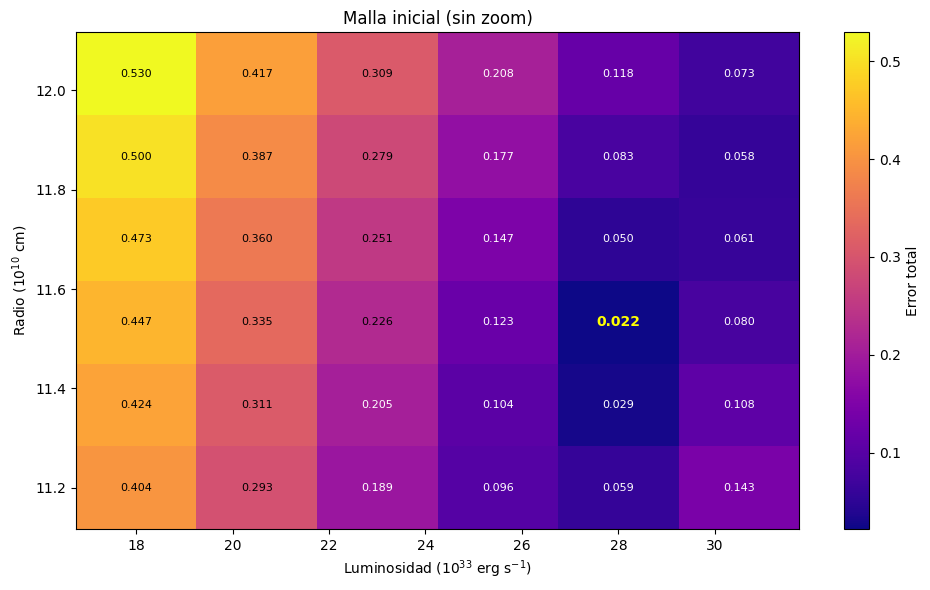

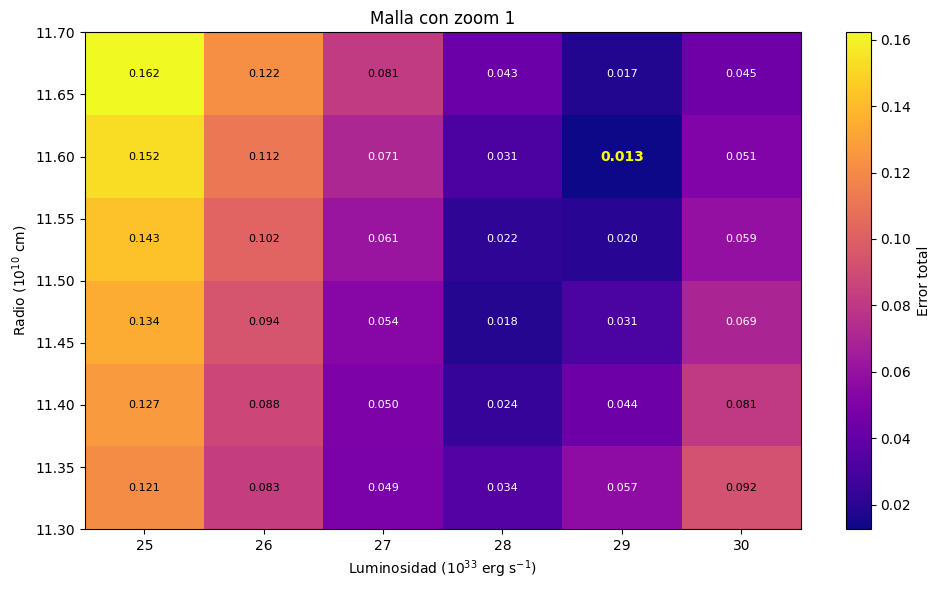

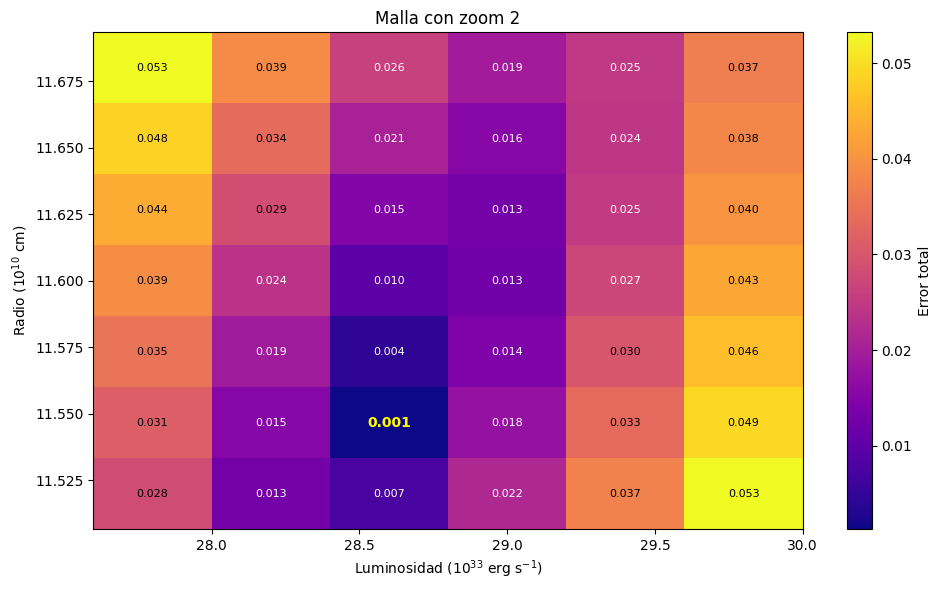

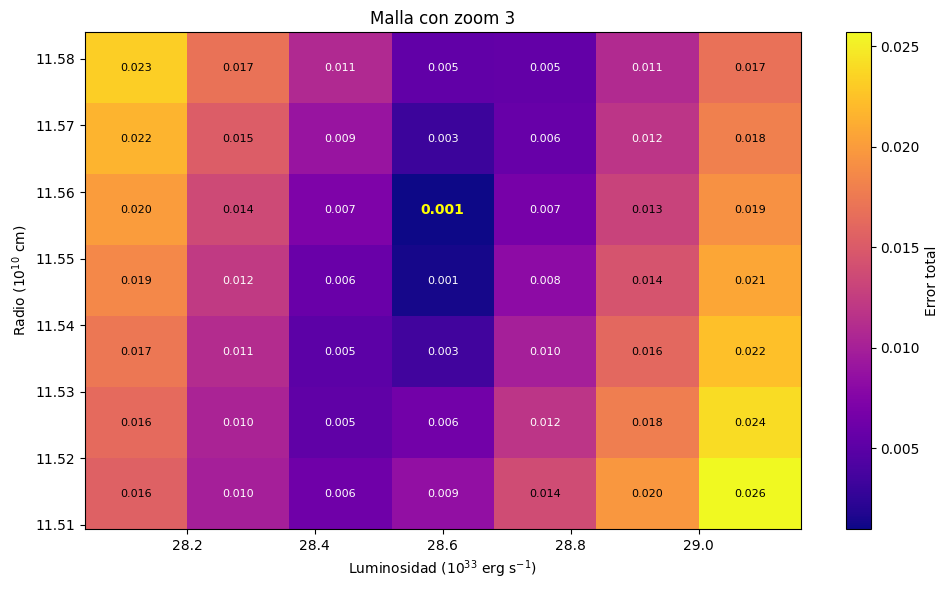

 Zoom     R_opt  L_opt  Error_min
    0 11.533333   28.0   0.021795
    1 11.600000   29.0   0.012629
    2 11.546667   28.6   0.001269
    3 11.557333   28.6   0.000965


In [11]:
def plot_malla(malla, indice, guardar=False):      # sirve para plotear las mallas mediante un diagrama de calor
    radios       = malla.index.values
    luminosidades = malla.columns.values
    valores      = malla.values
    R_min, L_min = malla.stack().idxmin()
    err_min      = malla.stack().min()

    fig, ax = plt.subplots(figsize=(10, 6))
    mapa = ax.pcolormesh(luminosidades, radios, valores,
                         cmap='plasma', shading='auto')
    cbar = fig.colorbar(mapa, ax=ax); cbar.set_label('Error total')

    for i_R, R in enumerate(radios):
        for i_L, L in enumerate(luminosidades):     # Bucle para imprimir el valor numérico del error dentro de cada  celda de la malla
            v = valores[i_R, i_L]
            es_min = (R == R_min and L == L_min)
            color = 'yellow' if es_min else ('white' if v < valores.mean() else 'black')
            peso  = 'bold'   if es_min else 'normal'
            ax.text(L, R, f'{v:.3f}', ha='center', va='center',
                    color=color, fontsize=10 if es_min else 8, fontweight=peso)

    titulo = "Malla inicial (sin zoom)" if indice == 0 else f"Malla con zoom {indice}"
    ax.set_title(titulo)
    ax.set_xlabel('Luminosidad ($10^{33}$ erg s$^{-1}$)')
    ax.set_ylabel('Radio ($10^{10}$ cm)')
    plt.tight_layout()
    if guardar:
        plt.savefig(f'Malla_{"inicial" if indice == 0 else f"zoom_{indice}"}.png',
                    dpi=150, bbox_inches='tight')
    plt.show()
    return R_min, L_min, err_min


resumen_zooms = []
for i, malla_actual in enumerate(mallas_calculadas):
    R_opt, L_opt, err = plot_malla(malla_actual, i, guardar=(i == 0))
    resumen_zooms.append({'Zoom': i, 'R_opt': R_opt, 'L_opt': L_opt, 'Error_min': err})

df_resumen = pd.DataFrame(resumen_zooms)
print(df_resumen.to_string(index=False))
df_resumen.to_csv('Resumen_zooms.csv', index=False)

            r          P         T         L        M        m Proceso
0   11.557333  0.0000000 0.0000000 28.600000 5.100000 0.000000      --
1   11.545776  0.0000000 0.0004668 28.600000 5.100000 0.000000      --
2   11.441760  0.0000000 0.0047104 28.600000 5.100000 0.000000      --
3   11.337744  0.0000000 0.0090319 28.600000 5.100000 0.000000      --
4   11.233728  0.0000002 0.0134335 28.600000 5.100000 0.000000      --
5   11.129712  0.0000007 0.0179173 28.600000 5.100000 0.000000      --
6   11.025696  0.0000020 0.0224857 28.600000 5.100000 0.000000      --
7   10.921680  0.0000044 0.0271411 28.600000 5.100000 0.000000      --
8   10.817664  0.0000087 0.0318860 28.600000 5.100000 0.000000      --
9   10.713648  0.0000158 0.0367231 28.600000 5.100000 0.000000      --
10  10.609632  0.0000270 0.0416550 28.600000 5.100000 0.000000      --
11  10.505616  0.0000438 0.0466846 28.600000 5.100000 0.000000      --
12  10.401600  0.0000682 0.0518148 28.600000 5.100000 0.000000      --
13  10

/tmp/ipykernel_1598/2206004494.py:30: RuntimeWarning: divide by zero encountered in scalar power
  eps_PP = comp.X**2 * eps_1_pp * comp.C_l * 10**nu_pp * P**2 * T**(nu_pp - 2)
/tmp/ipykernel_1598/2206004494.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  eps_PP = comp.X**2 * eps_1_pp * comp.C_l * 10**nu_pp * P**2 * T**(nu_pp - 2)
/tmp/ipykernel_1598/2206004494.py:31: RuntimeWarning: divide by zero encountered in scalar power
  eps_CN = comp.X * comp.Z / 3 * eps_1_cn * comp.C_l * 10**nu_cn * P**2 * T**(nu_cn - 2)
/tmp/ipykernel_1598/2206004494.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  eps_CN = comp.X * comp.Z / 3 * eps_1_cn * comp.C_l * 10**nu_cn * P**2 * T**(nu_cn - 2)


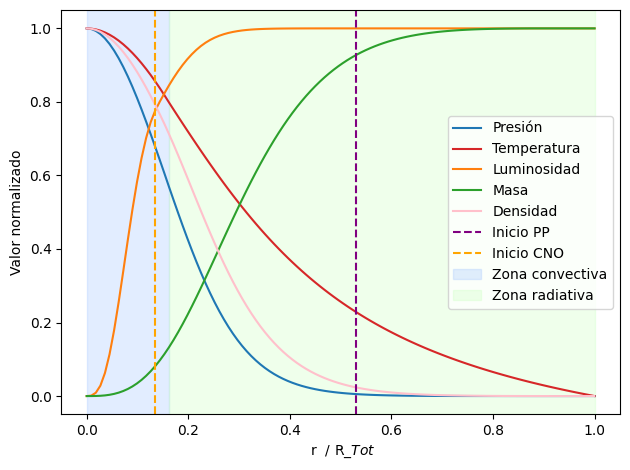

In [12]:
def Graficos_Modelo_Completo(df_variables, comp= comp_0 ):  # Muestra los valores del modelo y su representación gráfica normalizada
  df_variables = pd.DataFrame(df_variables, columns=['r', 'P', 'T', 'L', 'M', 'm'])
  r = df_variables['r']
  P = df_variables['P']
  T = df_variables['T']
  L = df_variables['L']
  M = df_variables['M']


  # Calculamos la densidad media con unidades en cgs
  P_cgs = P * 1e15
  T_cgs = T * 1e7

  densidad = comp.mu * H_cgs / k_cgs * P_cgs / T_cgs
  T_C_Optimizado_Final = T.iloc[-1]

  lista_proceso = [epsilon(P[i], T[i], comp)[1] for i in range(len(P))]
  df_variables['Proceso'] = lista_proceso
  df_variables_final.to_csv('Modelo_Completo.csv')
  print(df_variables.to_string(formatters=formatos_var))

  # Normalizamos los parámetros para la representación
  P_norm = P / P.max()
  T_norm = T / T.max()
  L_norm = L / L.max()
  M_norm = M / M.max()
  R_norm = r / r.max()
  rho = densidad / densidad.max()

  # Obtenemos los radios de interés físico (inicio PP, CNO, región convectiva)
  radio_pp = df_variables[df_variables['Proceso'] == 'PP']['r'].max() / r.max()
  radio_cno = df_variables_final[df_variables['Proceso'] == 'CNO']['r'].max() / r.max()

  radio_conv = df_variables[df_variables['m'] > 0]['r'].min() / r.max()
  radio_total = df_variables['r'].max() / r.max()


  figsize = (16, 10)
  plt.plot(R_norm, P_norm, label='Presión', color='#1f77b4')
  plt.plot(R_norm, T_norm, label='Temperatura', color='#d62728')
  plt.plot(R_norm, L_norm, label='Luminosidad', color='#ff7f0e')
  plt.plot(R_norm, M_norm, label='Masa', color='#2ca02c')
  plt.plot(R_norm, rho, label='Densidad', color='pink')


  plt.axvline(x=radio_pp, color='purple', linestyle='--', label='Inicio PP')
  plt.axvline(x=radio_cno, color='orange', linestyle='--', label='Inicio CNO')
  plt.axvspan(0, radio_conv, color='#a0c4ff', alpha=0.3, label='Zona convectiva')
  plt.axvspan(radio_conv, radio_total, color='#caffbf', alpha=0.3, label='Zona radiativa')

  plt.xlabel(' r  / R_${Tot} $')
  plt.ylabel('Valor normalizado')
  plt.legend()

  plt.tight_layout()
  plt.savefig('Graficos_Modelo_Completo')

Graficos_Modelo_Completo(df_variables_final)

In [13]:
def variar_parametros(X=X_0, Y=Y_0, M=M_Tot,
                      R= 11.7, L=18,
                      TC=TC_Optimizado_Final):

    # Variación de X
    historial_var_X = []
    X_var = np.arange(X - 0.02, X + 0.02, 0.004)

    R_prev, L_prev, TC_prev = R, L, TC
    for x in X_var:
        _, R_prev, L_prev, valor_min, TC_prev = optimizador_mallas(
            R_prev, L_prev, 0.1, 1, TC_prev, M,
            crear_composicion(x, Y), 4, 3)
        historial_var_X.append([x, R_prev, L_prev, valor_min, TC_prev,
                                 crear_composicion(x, Y).mu])

    historial_var_X = pd.DataFrame(historial_var_X,
                                   columns=['X', 'R', 'L', 'error', 'TC', 'mu'])

    # Variación de Y
    historial_var_Y = []
    Y_var = np.arange(Y - 0.02, Y + 0.02, 0.004)

    R_prev, L_prev, TC_prev = R, L, TC
    for y in Y_var:
        _, R_prev, L_prev, valor_min, TC_prev = optimizador_mallas(
            R_prev, L_prev, 0.1, 1, TC_prev, M,
            crear_composicion(X, y), 4, 3)
        historial_var_Y.append([y, R_prev, L_prev, valor_min, TC_prev,
                                 crear_composicion(X, y).mu])

    historial_var_Y = pd.DataFrame(historial_var_Y,
                                   columns=['Y', 'R', 'L', 'error', 'TC', 'mu'])

    # Variación de M
    historial_var_M = []
    M_var = np.arange(M - 0.3, M + 0.3, 0.05)

    R_prev, L_prev, TC_prev = R, L, TC
    for m in M_var:
        _, R_prev, L_prev, valor_min, TC_prev = optimizador_mallas(
            R_prev, L_prev, 0.1, 1.5, TC_prev, m,
            crear_composicion(X, Y), 4, 3)
        historial_var_M.append([m, R_prev, L_prev, valor_min, TC_prev])

    historial_var_M = pd.DataFrame(historial_var_M,
                                   columns=['M', 'R', 'L', 'error', 'TC'])

    return historial_var_X, historial_var_Y, historial_var_M


historial_var_X, historial_var_Y, historial_var_M = variar_parametros()
print(historial_var_X)
print(historial_var_Y)
print(historial_var_M)

        X        R       L     error        TC        mu
0   0.830  11.9496  22.760  0.009138  1.744188  0.564972
1   0.834  11.9256  23.760  0.000511  1.751883  0.563063
2   0.838  11.8432  24.696  0.000782  1.758791  0.561167
3   0.842  11.7464  25.792  0.000784  1.766368  0.559284
4   0.846  11.6544  27.096  0.000225  1.775221  0.557414
5   0.850  11.5552  28.600  0.000547  1.784873  0.555556
6   0.854  11.4408  30.360  0.001375  1.795530  0.553710
7   0.858  11.3344  32.600  0.000847  1.808354  0.551876
8   0.862  11.2072  35.264  0.000531  1.822492  0.550055
9   0.866  11.0680  38.568  0.000474  1.838850  0.548246
10  0.870  10.9184  42.832  0.000623  1.858079  0.546448
        Y        R       L     error        TC        mu
0   0.080  11.9608  20.536  0.001443  1.727970  0.557103
1   0.084  11.8928  21.776  0.000695  1.737858  0.556793
2   0.088  11.8104  23.112  0.001112  1.748215  0.556483
3   0.092  11.7368  24.712  0.000692  1.759628  0.556174
4   0.096  11.6480  26.488  0.0

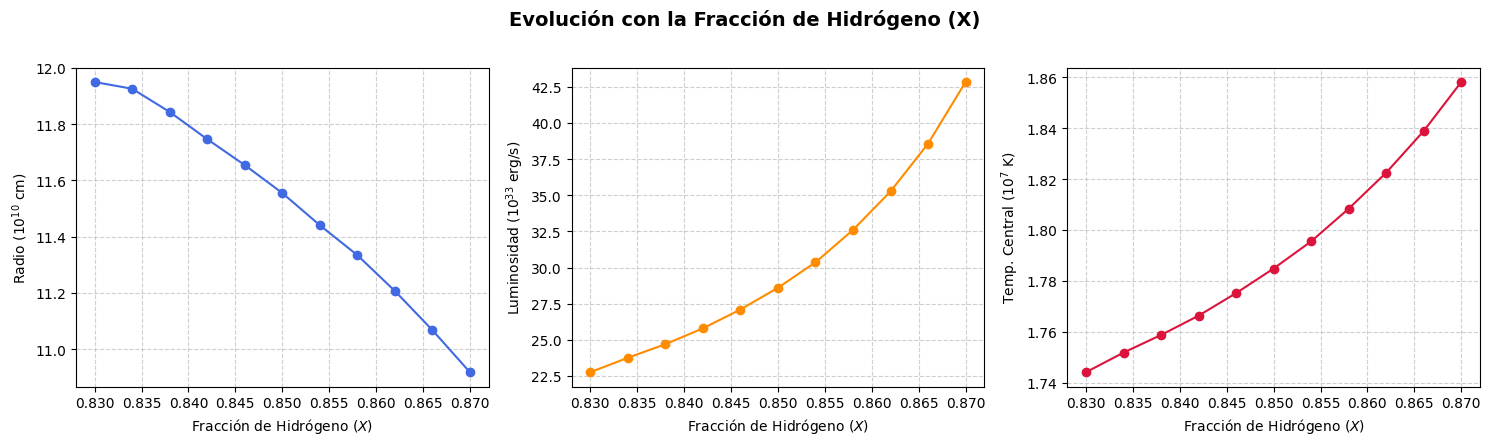

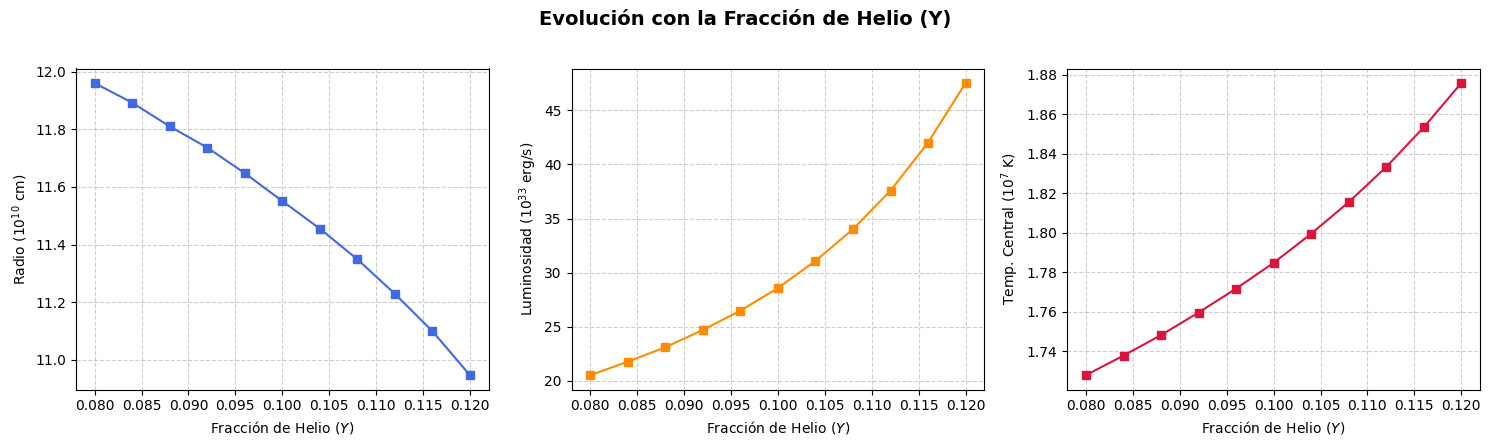

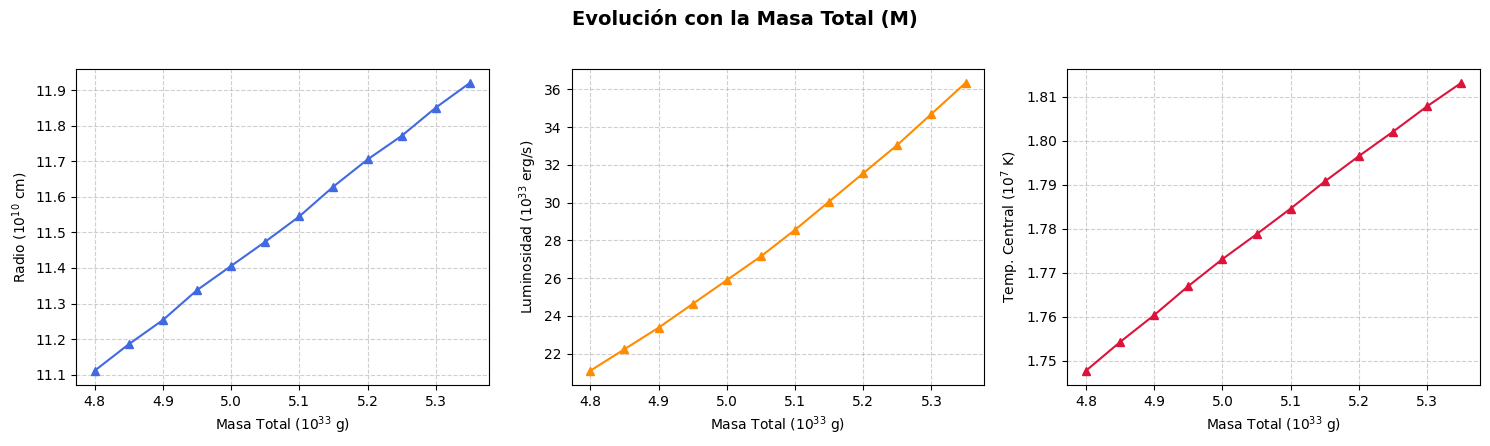

In [14]:
def plot_variacion(df, col_x, etiqueta_x, marker, titulo, filename):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    config = [
        ('R',  'Radio ($10^{10}$ cm)',         'royalblue'),
        ('L',  'Luminosidad ($10^{33}$ erg/s)', 'darkorange'),
        ('TC', 'Temp. Central ($10^7$ K)',     'crimson'),
    ]
    for ax, (col_y, label_y, color) in zip(axs, config):
        ax.plot(df[col_x], df[col_y], marker=marker, color=color)
        ax.set_ylabel(label_y)
        ax.set_xlabel(etiqueta_x)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


plot_variacion(historial_var_X, 'X', 'Fracción de Hidrógeno ($X$)', 'o',
               'Evolución con la Fracción de Hidrógeno (X)', 'Variacion_X.png')
plot_variacion(historial_var_Y, 'Y', 'Fracción de Helio ($Y$)', 's',
               'Evolución con la Fracción de Helio (Y)', 'Variacion_Y.png')
plot_variacion(historial_var_M, 'M', 'Masa Total ($10^{33}$ g)', '^',
               'Evolución con la Masa Total (M)', 'Variacion_M.png')




In [15]:
# Calculamos el ajuste y lo comparamos con el valor teórico
df_M_calc = historial_var_M[(historial_var_M['M'] > 0) & (historial_var_M['L'] > 0)].copy()

log_M = np.log10(df_M_calc['M'])
log_L = np.log10(df_M_calc['L'])
log_R = np.log10(df_M_calc['R'])
log_TC = np.log10(df_M_calc['TC'])


exp_L, _ = np.polyfit(log_M, log_L, 1)
exp_R, _ = np.polyfit(log_M, log_R, 1)
exp_TC, _ = np.polyfit(log_M, log_TC, 1)

exp_L_teo = 5.1
exp_R_teo = 2/3
exp_TC_teo = 1/3

err_L = abs(exp_L - exp_L_teo) / abs(exp_L_teo) * 100
err_R = abs(exp_R - exp_R_teo) / abs(exp_R_teo) * 100
err_TC = abs(exp_TC - exp_TC_teo) / abs(exp_TC_teo) * 100


print("            RELACIONES DE HOMOLOGÍA OBTENIDAS PARA LA MASA")
print(f"Relación Masa-Luminosidad  : L  ∝ M^{exp_L:.3f}   | Teórico: {exp_L_teo:.3f} | Error: {err_L:.2f}%")
print(f"Relación Masa-Radio        : R  ∝ M^{exp_R:.3f}   | Teórico: {exp_R_teo:.3f} | Error: {err_R:.2f}%")
print(f"Relación Masa-Temp. Central: Tc ∝ M^{exp_TC:.3f}   | Teórico: {exp_TC_teo:.3f} | Error: {err_TC:.2f}%")



            RELACIONES DE HOMOLOGÍA OBTENIDAS PARA LA MASA
Relación Masa-Luminosidad  : L  ∝ M^5.019   | Teórico: 5.100 | Error: 1.58%
Relación Masa-Radio        : R  ∝ M^0.649   | Teórico: 0.667 | Error: 2.61%
Relación Masa-Temp. Central: Tc ∝ M^0.338   | Teórico: 0.333 | Error: 1.52%


In [16]:
def virial(df_variables, comp):
    # Pasamos a CGS desde las unidades del modelo
    r_cgs   = df_variables['r'] * 1e10
    P_cgs   = df_variables['P'] * 1e15
    T_cgs   = df_variables['T'] * 1e7
    M_cgs   = df_variables['M'] * 1e33
    densidad = comp.mu * H_cgs / k_cgs * P_cgs / T_cgs

    filtro = (densidad > 0) & (r_cgs > 0)              # Puesto que tenemos 0s, los filtramos para evitar problemas de convergencia
    r_cgs, M_cgs, densidad, P_cgs = (
        r_cgs[filtro], M_cgs[filtro], densidad[filtro], P_cgs[filtro]
    )

    EG = simpson(y=4 * np.pi * G_cgs * M_cgs * r_cgs * densidad, x=r_cgs)
    U  = 1.5 * simpson(y=-4 * np.pi * r_cgs**2 * P_cgs, x=r_cgs)
    error = 100 * (2 * U + EG) / abs(EG)

    print(f"Energía Gravitatoria (EG): {EG:.4e}")
    print(f"Energía Interna (U): {U:.4e}")
    print(f"Error relativo cometido: {error:.3f} %")


virial(df_variables_final, comp_0)

Energía Gravitatoria (EG): -2.1892e+49
Energía Interna (U): 1.0946e+49
Error relativo cometido: -0.003 %


Diagrama HR

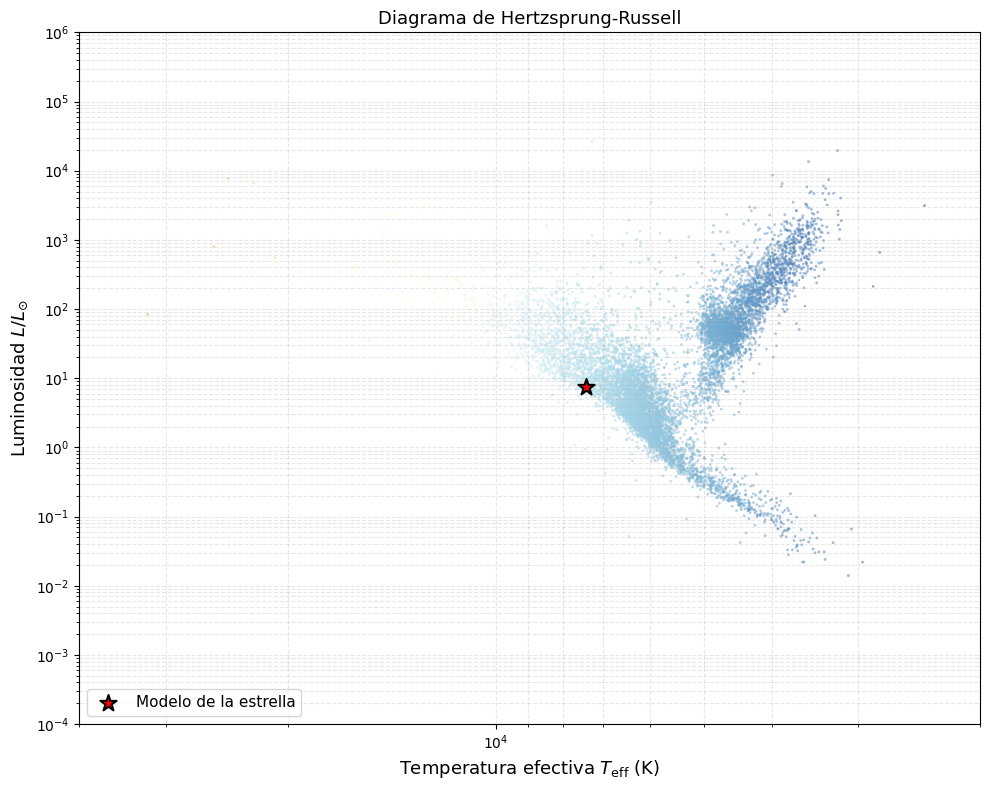


A continuación se muestran las estrellas más similares a nuestro modelo
---------------------------------------------------------------------------
HIP ID     | T_eff (K)  | L (L_sol)  | R (R_sol)  | M (M_sol) 
---------------------------------------------------------------------------
HIP 8809   | 7390       | 7.57       | 1.68       | 1.48      
HIP 9532   | 7230       | 7.50       | 1.75       | 1.44      
HIP 7644   | 7299       | 7.29       | 1.69       | 1.45      
HIP 5830   | 7481       | 7.25       | 1.61       | 1.50      
HIP 959    | 7387       | 7.24       | 1.64       | 1.47      
---------------------------------------------------------------------------
MODELO     | 7404       | 7.47       | 1.66       | 2.56      
---------------------------------------------------------------------------
ERR (%)    | 0.63       | 1.39       | 0.75       | 74.68     


In [17]:
def Localización_HR(L_opt, R_opt, M):
    # Pasamos a unidades cgs y a unidades solares
    L_opt_cgs = L_opt * 1e33
    R_opt_cgs = R_opt * 1e10
    L_abs = L_opt_cgs / L_sol
    R_abs = R_opt_cgs / R_sol
    T_eff = (L_opt_cgs / (4 * np.pi * R_opt_cgs**2 * sigma))**0.25
    M_abs = M / 1.989

    # Descarga del catálogo
    v = Vizier(row_limit=10000)
    catalog = v.get_catalogs('J/MNRAS/471/770/table2')[0]
    df_HR = catalog.to_pandas()
    df_HR = df_HR.rename(columns={'Teff': 'T_eff_real', 'L': 'L_real', 'Rad': 'R_real'})
    df_HR['Masa_real'] = 10**(df_HR['log(g)'] - 4.44 + 2 * np.log10(df_HR['R_real']))

    T_HR = df_HR['T_eff_real']
    L_HR = df_HR['L_real']

    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(T_HR, L_HR, c=T_HR, cmap='RdYlBu_r',
                    s=4, alpha=0.5, edgecolors='none',
                    norm=colors.LogNorm())

    ax.scatter(T_eff, L_abs, s=150, color='red', marker='*',
              edgecolors='black', linewidth=1.5,
              label='Modelo de la estrella', zorder=10)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_xlim(40000, 2000)
    ax.set_ylim(1e-4, 1e6)

    ax.set_xlabel('Temperatura efectiva $T_{\\mathrm{eff}}$ (K)', fontsize=13)
    ax.set_ylabel('Luminosidad $L/L_{\\odot}$', fontsize=13)
    ax.set_title('Diagrama de Hertzsprung-Russell', fontsize=13)
    ax.grid(True, which='both', alpha=0.3, linestyle='--')
    ax.legend(loc='lower left', fontsize=11)

    plt.tight_layout()
    plt.savefig('Diagrama_HR.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Búsqueda de estrellas similares por distancia
    log_T_teo = np.log10(T_eff)
    log_L_teo = np.log10(L_abs)
    log_T_obs = np.log10(df_HR['T_eff_real'])
    log_L_obs = np.log10(df_HR['L_real'])

    df_HR['Distancia_HR'] = np.sqrt((log_T_obs - log_T_teo)**2 + (log_L_obs - log_L_teo)**2)
    estrellas_similares = df_HR.sort_values('Distancia_HR').head(5)

    print("\nA continuación se muestran las estrellas más similares a nuestro modelo")
    print("-" * 75)
    print(f"{'HIP ID':<10} | {'T_eff (K)':<10} | {'L (L_sol)':<10} | {'R (R_sol)':<10} | {'M (M_sol)':<10}")
    print("-" * 75)

    for _, row in estrellas_similares.iterrows():
        print(f"HIP {int(row['HIP']):<6} | {row['T_eff_real']:<10.0f} | {row['L_real']:<10.2f} | {row['R_real']:<10.2f} | {row['Masa_real']:<10.2f}")

    print("-" * 75)
    print(f"{'MODELO':<10} | {T_eff:<10.0f} | {L_abs:<10.2f} | {R_abs:<10.2f} | {M_abs:<10.2f}")

    # Error relativo del modelo frente a la media de las análogas
    T_media = estrellas_similares['T_eff_real'].mean()
    L_media = estrellas_similares['L_real'].mean()
    R_media = estrellas_similares['R_real'].mean()
    M_media = estrellas_similares['Masa_real'].mean()

    err_T = abs(T_eff - T_media) / T_media * 100
    err_L = abs(L_abs - L_media) / L_media * 100
    err_R = abs(R_abs - R_media) / R_media * 100
    err_M = abs(M_abs - M_media) / M_media * 100

    print("-" * 75)
    print(f"{'ERR (%)':<10} | {err_T:<10.2f} | {err_L:<10.2f} | {err_R:<10.2f} | {err_M:<10.2f}")


    return T_eff, L_abs, R_abs, M_abs


T_eff, L_abs, R_abs, M_abs = Localización_HR(L_Optimizado_Final, R_Optimizado_Final, M_Tot)

Evolución temporal

In [18]:
def Evolucion_t(X0, Y0, M, L, T_C, R, n = 15) :
  t = 0
  c_cgs = 2.998e10
  eta = 0.007
  M_cgs = M * 1e33
  L_cgs = L * 1e33
  historial = []
  historial_modelos = []
  # Desarrollo explicado en la memoria
  tau_SP_años = t_sol_MS * (M / 1.989)**(-2.5)
  delta_t = tau_SP_años / n
  delta_t_seg = delta_t * seg_por_año
  X, Y = X0, Y0
  comp_inicial = crear_composicion(X, Y)
  mu_0 = comp_inicial.mu
  delta_M_H = L_cgs * delta_t_seg / (eta * c_cgs**2)
  delta_X = delta_M_H / M_cgs
  R_actual, L_actual, T_C_actual = R, L, T_C
  while t <= tau_SP_años:  # Obtenemos datos hasta la finalización de la secuencia principal
    delta_M_H = (L_actual * 1e33) * delta_t_seg / (eta * c_cgs**2)
    delta_X = delta_M_H / M_cgs
    X = X - delta_X
    Y = Y + delta_X
    nueva_comp = crear_composicion(X, Y)
    # Reoptimizamos R y L con la nueva composición, partiendo del par óptimo anterior
    _, R_actual, L_actual, error_mod, T_C_actual = optimizador_mallas(
    R_actual, L_actual, 0.1, 0.5, T_C_actual, M, nueva_comp, 3, 4)
    variables_modelo, _, _, _ = ModeloCompleto(L_actual, M, T_C_actual, R_actual, nueva_comp)


    L_actual_cgs = L_actual * 1e33
    R_actual_cgs = R_actual * 1e10
    T_eff = (L_actual_cgs / (4 * np.pi * R_actual_cgs**2 * sigma))**0.25

    historial.append([t, t/(1e6), X, Y, nueva_comp.mu, L_actual, R_actual, T_C_actual,  T_eff, error_mod])
    historial_modelos.append(variables_modelo)
    t += delta_t

  return historial, variables_modelo

Historial_estelar, variables_t = Evolucion_t(X_0, Y_0, M_Tot, L_Optimizado_Final, TC_Optimizado_Final, R_Optimizado_Final)

In [19]:
df_evol = pd.DataFrame(Historial_estelar,
                       columns=['t','t(Maños)', 'X', 'Y', 'mu', 'L_modelo', 'R_modelo','TC', 'T_eff', 'error_mod'])


df_evol['L_sol'] = df_evol['L_modelo']  / 3.828
df_evol['R_sol'] = df_evol['R_modelo'] / 6.963


print(df_evol)

               t    t(Maños)         X         Y        mu  L_modelo  \
0   0.000000e+00    0.000000  0.848219  0.101781  0.556244   28.8808   
1   6.332428e+07   63.324280  0.846420  0.103580  0.556940   29.1680   
2   1.266486e+08  126.648559  0.844603  0.105397  0.557645   29.4552   
3   1.899728e+08  189.972839  0.842769  0.107231  0.558360   29.7424   
4   2.532971e+08  253.297119  0.840916  0.109084  0.559082   30.0424   
5   3.166214e+08  316.621399  0.839045  0.110955  0.559814   30.3488   
6   3.799457e+08  379.945678  0.837155  0.112845  0.560556   30.6680   
7   4.432700e+08  443.269958  0.835245  0.114755  0.561307   30.9872   
8   5.065942e+08  506.594238  0.833315  0.116685  0.562068   31.3192   
9   5.699185e+08  569.918517  0.831364  0.118636  0.562840   31.6512   
10  6.332428e+08  633.242797  0.829393  0.120607  0.563621   32.0024   
11  6.965671e+08  696.567077  0.827399  0.122601  0.564414   32.3536   
12  7.598914e+08  759.891356  0.825384  0.124616  0.565218   32.

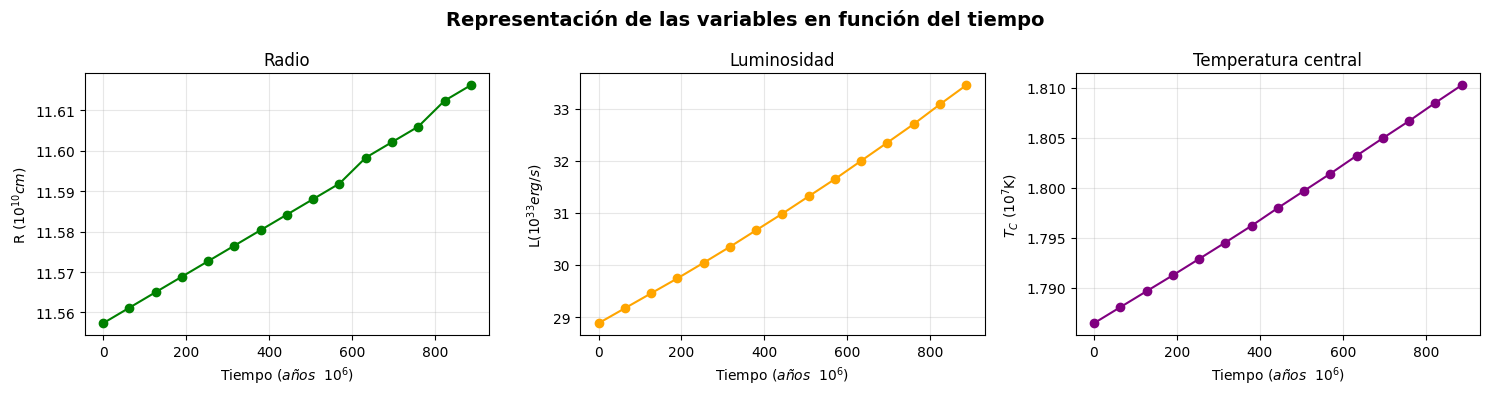

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Representación de las variables en función del tiempo',
             fontsize=14, fontweight='bold')


axes[0].plot(df_evol['t(Maños)'], df_evol['R_modelo'], 'o-', color='green')
axes[0].set_xlabel('Tiempo ($años$  $10^6$)')
axes[0].set_ylabel('R ($10^{10} cm$)')
axes[0].set_title('Radio')
axes[0].grid(alpha=0.3)

axes[1].plot(df_evol['t(Maños)'], df_evol['L_modelo'], 'o-', color='orange')
axes[1].set_xlabel('Tiempo ($años$  $10^6$)')
axes[1].set_ylabel('L($10^{33} erg/s$)')
axes[1].set_title('Luminosidad')
axes[1].grid(alpha=0.3)

axes[2].plot(df_evol['t(Maños)'], df_evol['TC'], 'o-', color='purple')
axes[2].set_xlabel('Tiempo ($años$  $10^6$)')
axes[2].set_ylabel('$T_C$ ($10^7$K)')
axes[2].set_title('Temperatura central')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Evolucion_observables.png', dpi=150, bbox_inches='tight')
plt.show()

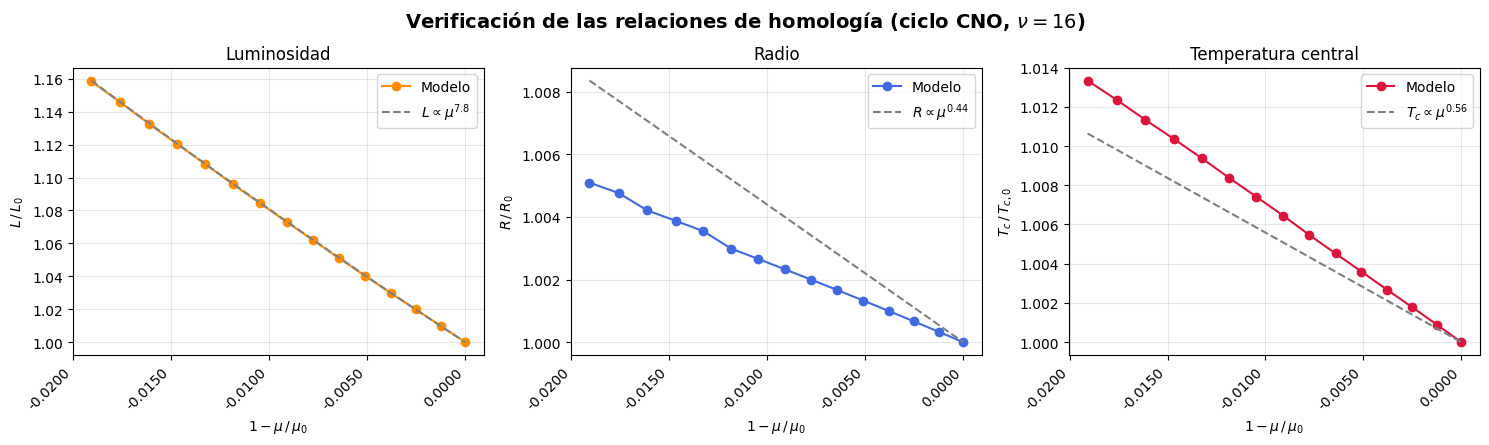

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Verificación de las relaciones de homología (ciclo CNO, $\\nu = 16$)',
             fontsize=14, fontweight='bold')

mu_t = df_evol['mu']
mu_ratio = mu_t / mu_t.iloc[0]

x_datos = 1 - mu_ratio
x_th = np.linspace(x_datos.min(), x_datos.max(), 50)
mu_th_real = 1 - x_th  # mu/mu_0 correspondiente a cada x

# Luminosidad
L_ratio = df_evol['L_sol'] / df_evol['L_sol'].iloc[0]
axs[0].plot(x_datos, L_ratio, 'o-', color='darkorange', label='Modelo')
axs[0].plot(x_th, mu_th_real**7.8, '--', color='gray',
            label=r'$L \propto \mu^{7.8}$')
axs[0].set_xlabel(r'$1 - \mu\,/\,\mu_0$')
axs[0].set_ylabel(r'$L\,/\,L_0$')
axs[0].set_title('Luminosidad')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Radio
R_ratio = df_evol['R_sol'] / df_evol['R_sol'].iloc[0]
axs[1].plot(x_datos, R_ratio, 'o-', color='royalblue', label='Modelo')
axs[1].plot(x_th, mu_th_real**0.44, '--', color='gray',
            label=r'$R \propto \mu^{0.44}$')
axs[1].set_xlabel(r'$1 - \mu\,/\,\mu_0$')
axs[1].set_ylabel(r'$R\,/\,R_0$')
axs[1].set_title('Radio')
axs[1].legend()
axs[1].grid(alpha=0.3)

# Temperatura central
TC_ratio = df_evol['TC'] / df_evol['TC'].iloc[0]
axs[2].plot(x_datos, TC_ratio, 'o-', color='crimson', label='Modelo')
axs[2].plot(x_th, mu_th_real**0.56, '--', color='gray',
            label=r'$T_c \propto \mu^{0.56}$')
axs[2].set_xlabel(r'$1 - \mu\,/\,\mu_0$')
axs[2].set_ylabel(r'$T_c\,/\,T_{c,0}$')
axs[2].set_title('Temperatura central')
axs[2].legend()
axs[2].grid(alpha=0.3)

from matplotlib.ticker import FormatStrFormatter
for ax in axs:
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig('Homologias_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()